# Admission Chances using Keras

### Load libraries

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense

In [47]:
print(keras.__version__)

3.14.0


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Load data from admissions.csv 

In [49]:
df = pd.read_csv("admission.csv")

In [50]:
X = df[['Gre','Toefl','Cgpa']]
y = df['Chance']

In [51]:
X.sample(10)

,Gre,Toefl,Cgpa
408,297,101,7.67
394,329,111,9.23
391,318,106,8.65
7,308,101,7.90
439,312,105,8.46
327,295,101,7.86
415,327,106,8.75
116,299,102,8.62
422,322,112,9.02
141,332,118,9.36


In [52]:
y.sample(10)

234    0.91
5      0.90
213    0.96
387    0.53
380    0.78
112    0.62
276    0.89
182    0.68
404    0.62
272    0.49
Name: Chance, dtype: float64

## Standardization of DataSet

In [53]:
mm = MinMaxScaler()

In [54]:
# Split data into train and test 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [55]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((400, 3), (100, 3), (400,), (100,))

In [56]:
# Scale Train data 
X_train_scaled = mm.fit_transform(X_train)

In [57]:
#Scale Test data 
X_test_scaled = mm.transform(X_test)

In [58]:
X_train_scaled[:5]

array([[0.96      , 0.89285714, 0.8525641 ],
       [0.58      , 0.64285714, 0.63782051],
       [0.92      , 0.71428571, 0.94871795],
       [0.36      , 0.46428571, 0.36858974],
       [0.62      , 0.60714286, 0.44871795]])

In [59]:
# Model
model = keras.Sequential([
    keras.Input(shape=(3,)),
    keras.layers.Dense(3, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

In [60]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 3)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.layers

[<Dense name=dense_4, built=True>, <Dense name=dense_5, built=True>]

In [62]:
model.get_weights()

[array([[ 0.00545549,  0.8885207 , -0.5442531 ],
        [-0.6452718 ,  0.17783976,  0.8006449 ],
        [-0.4032688 ,  0.7181032 ,  0.15803027]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[-0.259324  ],
        [-0.47275728],
        [ 0.62929344]], dtype=float32),
 array([0.], dtype=float32)]

In [63]:
model.compile(loss="mse",  optimizer="adam",  metrics = ['mae'])

In [68]:
history = model.fit(X_train_scaled, y_train, epochs = 20)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2210 - mae: 0.4413 
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1813 - mae: 0.3971 
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1484 - mae: 0.3560 
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1204 - mae: 0.3175 
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0975 - mae: 0.2827 
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0788 - mae: 0.2511 
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0639 - mae: 0.2239 
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0516 - mae: 0.1995 
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0421 - mae: 0.1786 
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0348 - mae: 0.1607 
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0293 - mae: 0.1456 
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0250 - mae: 0.1328 
Epoch 13/20
13/13 ━━━━━━━━━━━━━━━━━━━

In [70]:
y_test_p = model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [69]:
y_test_p[:10]

array([[0.2231319 ],
       [0.37075195],
       [0.30026117],
       [0.3327826 ],
       [0.33519924],
       [0.24621415],
       [0.34968835],
       [0.51211745],
       [0.3378362 ],
       [0.12076295]], dtype=float32)

<Axes: >

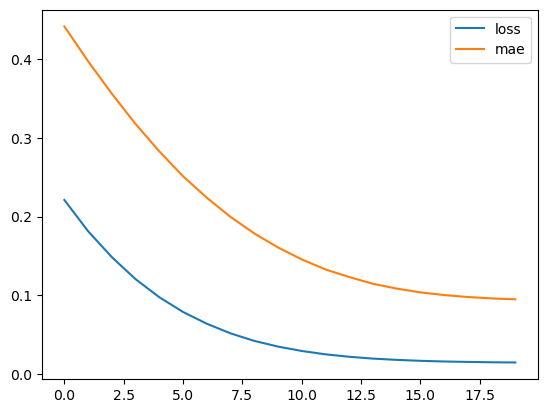

In [71]:
pd.DataFrame(history.history).plot()